# #️⃣ File 03.Campaign Effectiveness Analysis

## #️⃣ 1. Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

spend_df = pd.read_excel("Spend (Result).xlsx")
deals_df = pd.read_excel("Deals_clean.xlsx")
calls_df = pd.read_excel("Calls (Result).xlsx")

## #️⃣ 2. Adding Revenue and AOV Calculation

In [3]:
def calc_revenue(row):
    # Revenue only for Payment Done
    if row["Stage"] != "Payment Done":
        return 0

    # Revenue only for MAIN_PRODUCTS
    if row["Product"] not in ["Digital Marketing", "UX/UI Design", "Web Developer"]:
        return 0

    initial = row["Initial Amount Paid"]
    offer = row["Offer Total Amount"]
    cd = row["Course duration"]
    ms = row["Months of study"]

    # no Initial → no revenue
    if pd.isna(initial):
        return 0

    # no Offer → revenue = Initial
    if pd.isna(offer):
        return initial

    # no duration → revenue = Initial
    if pd.isna(cd) or cd <= 1:
        return initial

    # no months → revenue = Initial
    if pd.isna(ms) or ms <= 1:
        return initial

    # monthly payment
    monthly_payment = (offer - initial) / (cd - 1)

    # actual revenue
    revenue = initial + monthly_payment * (ms - 1)

    # revenue cannot exceed Offer
    return min(revenue, offer)

deals_df["Revenue"] = deals_df.apply(calc_revenue, axis=1)

# AOV
deals_df["AOV"] = deals_df["Revenue"] / deals_df["Months of study"].replace(0, 1)

# Is_won flag
deals_df["Is_won"] = deals_df["Stage"] == "Payment Done"

## #️⃣ 3. Spend Aggregation

In [4]:
spend_agg = (
    spend_df.groupby("Campaign")
    .agg(
        Spend=("Spend", "sum"),
        Clicks=("Clicks", "sum"),
        Impressions=("Impressions", "sum")
    )
    .reset_index()
)

spend_agg.head()

,Campaign,Spend,Clicks,Impressions
0,01.02.24wide_webinar_DE,189.91,195,18047
1,01.04.23women_PL,357.25,367,45956
2,02.05.24test_DE,164.04,790,20047
3,02.07.23wide_DE,6913.60,10281,594807
4,02.08.23interests_DE,69.30,76,5990


### 🔍 Insight
 ✔ Spend is now clean and aggregated  
 ✔ Ready to calculate CTR, CPC, CAC, ROI

## #️⃣ 4. Linking Spend → Deals

In [5]:
deals_by_campaign = (
    deals_df.groupby("Campaign")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

deals_by_campaign["AOV"] = (
    deals_by_campaign["Revenue"] /
    deals_by_campaign["Deals_won"].replace(0, np.nan)
)

deals_by_campaign = deals_by_campaign.sort_values("Revenue", ascending=False)
deals_by_campaign = deals_by_campaign.round(2)
deals_by_campaign.head(5)

,Campaign,Deals_count,Deals_won,Revenue,AOV
118,performancemax_digitalmarkt_ru_DE,2653,112,495315.0,4422.46
2,02.07.23wide_DE,975,52,264570.0,5087.88
152,youtube_shorts_DE,1635,53,213500.0,4028.30
18,12.07.2023wide_DE,1575,48,196455.0,4092.81
4,03.07.23women,612,31,155750.0,5024.19


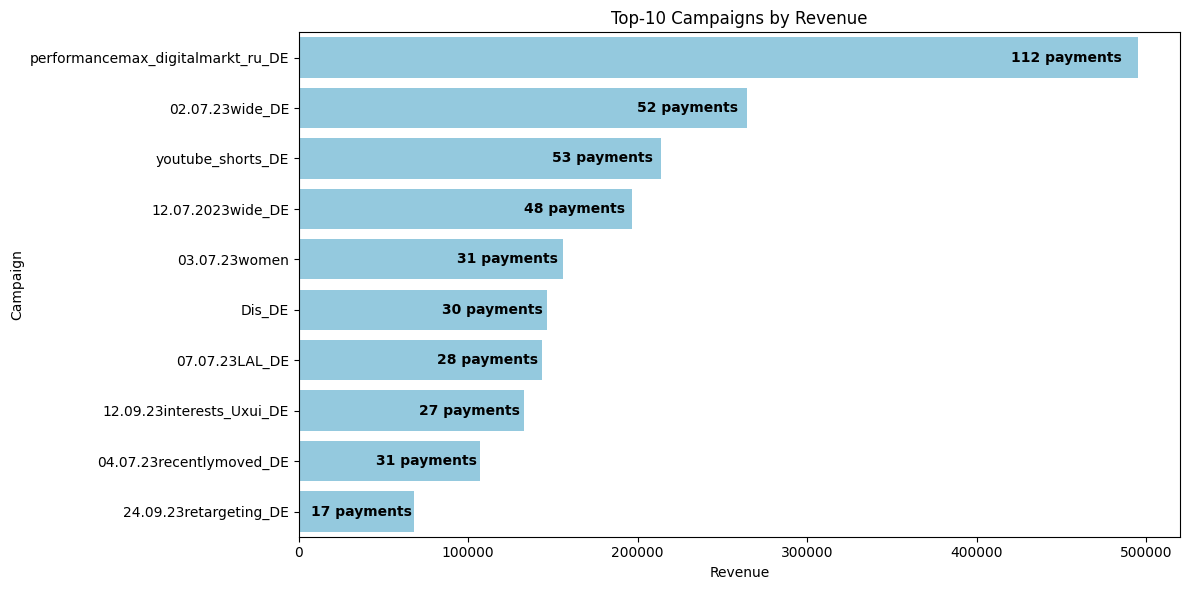

In [6]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=deals_by_campaign.head(10),
    x="Revenue",
    y="Campaign",
    color="skyblue"
)

plt.title("Top‑10 Campaigns by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Campaign")

for bar, (_, row) in zip(ax.patches, deals_by_campaign.head(10).iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax.text(
        width * 0.98,
        y,
        f'{int(row["Deals_won"])} payments',
        va='center',
        ha='right',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 🔍 Insight
 ✔ For each campaign: number of deals, paid deals, revenue  
 ✔ AOV considers only paid deals

## #️⃣ 5. Merging Spend + Deals

In [7]:
campaign_perf = spend_agg.merge(deals_by_campaign, on="Campaign", how="left")

campaign_perf.fillna({
    "Deals_count": 0,
    "Deals_won": 0,
    "Revenue": 0
}, inplace=True)

campaign_perf = campaign_perf.sort_values("Revenue", ascending=False)
campaign_perf = campaign_perf.round(2)
campaign_perf.head()

,Campaign,Spend,Clicks,Impressions,Deals_count,Deals_won,Revenue,AOV
3,02.07.23wide_DE,6913.60,10281,594807,975.0,52.0,264570.0,5087.88
50,youtube_shorts_DE,14149.22,57873,8481054,1635.0,53.0,213500.0,4028.30
16,12.07.2023wide_DE,9471.52,22768,3302301,1575.0,48.0,196455.0,4092.81
5,03.07.23women,4219.75,7139,348089,612.0,31.0,155750.0,5024.19
9,07.07.23LAL_DE,4200.37,5813,335725,542.0,28.0,143835.0,5136.96


### 🔍 Insight
 ✔ Spend and Deals are linked by Campaign  
 ✔ Campaigns are fully connected to sales  

## #️⃣ 6. Calculating Key Performance Metrics

In [8]:
campaign_perf["CTR"] = campaign_perf["Clicks"] / campaign_perf["Impressions"].replace(0, np.nan)
campaign_perf["CPC"] = campaign_perf["Spend"] / campaign_perf["Clicks"].replace(0, np.nan)
campaign_perf["CAC"] = campaign_perf["Spend"] / campaign_perf["Deals_won"].replace(0, np.nan)
campaign_perf["CR"] = campaign_perf["Deals_won"] / campaign_perf["Deals_count"].replace(0, np.nan)
campaign_perf["ROI"] = campaign_perf["Revenue"] / campaign_perf["Spend"].replace(0, np.nan)

campaign_perf = campaign_perf.sort_values("Revenue", ascending=False)
campaign_perf = campaign_perf.round(2)
campaign_perf.head()

,Campaign,Spend,Clicks,Impressions,Deals_count,Deals_won,Revenue,AOV,CTR,CPC,CAC,CR,ROI
3,02.07.23wide_DE,6913.60,10281,594807,975.0,52.0,264570.0,5087.88,0.02,0.67,132.95,0.05,38.27
50,youtube_shorts_DE,14149.22,57873,8481054,1635.0,53.0,213500.0,4028.30,0.01,0.24,266.97,0.03,15.09
16,12.07.2023wide_DE,9471.52,22768,3302301,1575.0,48.0,196455.0,4092.81,0.01,0.42,197.32,0.03,20.74
5,03.07.23women,4219.75,7139,348089,612.0,31.0,155750.0,5024.19,0.02,0.59,136.12,0.05,36.91
9,07.07.23LAL_DE,4200.37,5813,335725,542.0,28.0,143835.0,5136.96,0.02,0.72,150.01,0.05,34.24


### 🔍 Insight
 ✔ All key marketing metrics calculated  
 ✔ Campaigns can now be compared by efficiency  

## #️⃣ 7. Top‑10 Campaigns by Revenue

<Figure size 1400x600 with 0 Axes>

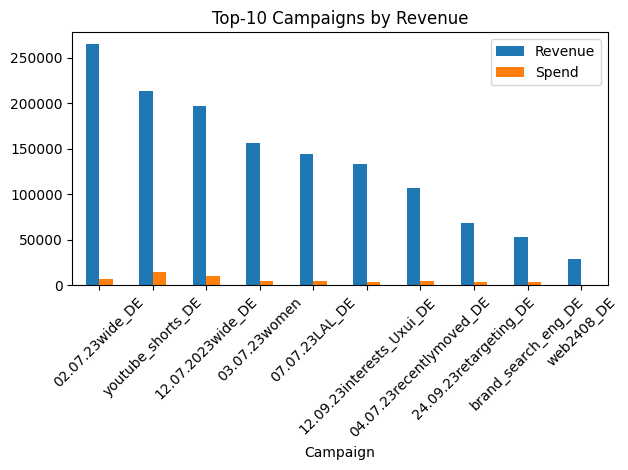

In [9]:
profit_sorted = campaign_perf.sort_values("Revenue", ascending=False)
profit_sorted.head(10)

top = campaign_perf.sort_values("Revenue", ascending=False).head(10)

plt.figure(figsize=(14, 6))
top.plot(
    x="Campaign",
    y=["Revenue", "Spend"],
    kind="bar",
    title="Top‑10 Campaigns by Revenue"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🔍 Insight
 ✔ Revenue leaders: wide_DE, youtube_shorts_DE, women  
 ✔ All top campaigns are profitable — ROI > 0  
 ✔ YouTube Shorts — strong channel worth scaling  
 ✔ interest and recentlymoved — high CR and low CAC  
 ✔ High‑Spend but mid‑Revenue campaigns require deeper analysis  

## #️⃣ 8. Source Effectiveness Analysis

In [10]:
source_perf = (
    deals_df.groupby("Source")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

source_perf["CR"] = source_perf["Deals_won"] / source_perf["Deals_count"].replace(0, np.nan)
source_perf["AOV"] = source_perf["Revenue"] / source_perf["Deals_won"].replace(0, np.nan)

source_perf = source_perf.round(2)
source_perf = source_perf.sort_values("Deals_won", ascending=False)
source_perf.head()

,Source,Deals_count,Deals_won,Revenue,CR,AOV
2,Facebook Ads,4850,202,929615.0,0.04,4602.05
3,Google Ads,4226,173,731500.0,0.04,4228.32
5,Organic,2590,147,599865.0,0.06,4080.71
7,SMM,1730,91,302330.0,0.05,3322.31
10,Tiktok Ads,2051,56,216585.0,0.03,3867.59


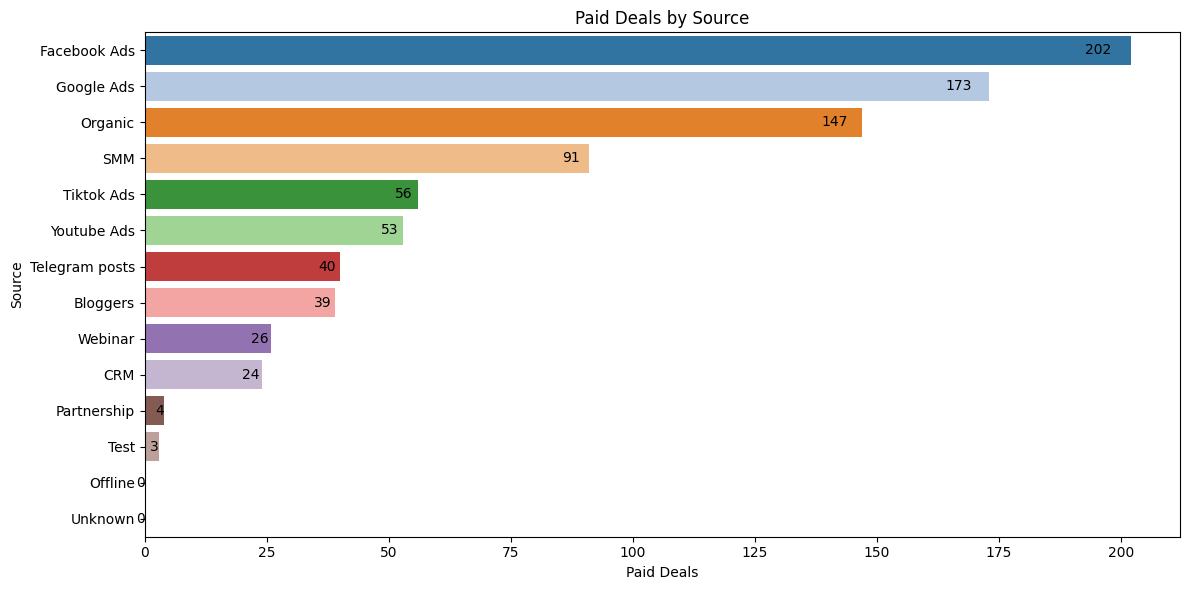

In [11]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=source_perf,
    x="Deals_won",
    y="Source",
    hue="Source",
    palette="tab20",
    dodge=False,
    legend=False
)

plt.title("Paid Deals by Source")
plt.xlabel("Paid Deals")
plt.ylabel("Source")

for bar, (_, row) in zip(ax.patches, source_perf.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(width*0.98, y, int(row["Deals_won"]), va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

### 🔍 Insights
 ✔ Facebook Ads — revenue leader  
 ✔ Google Ads — sales leader  
 ✔ Organic — best lead quality (CR = 6%)  
 ✔ SMM — stable channel with good CR  
 ✔ Tiktok Ads — low conversion but high AOV  

### Required actions:
- Scale: Facebook Ads, Google Ads, Organic, SMM  

- Optimize: Tiktok Ads  

- Strengthen brand: Organic grows fastest

## #️⃣ 9. Monthly Trend of Deals and Calls

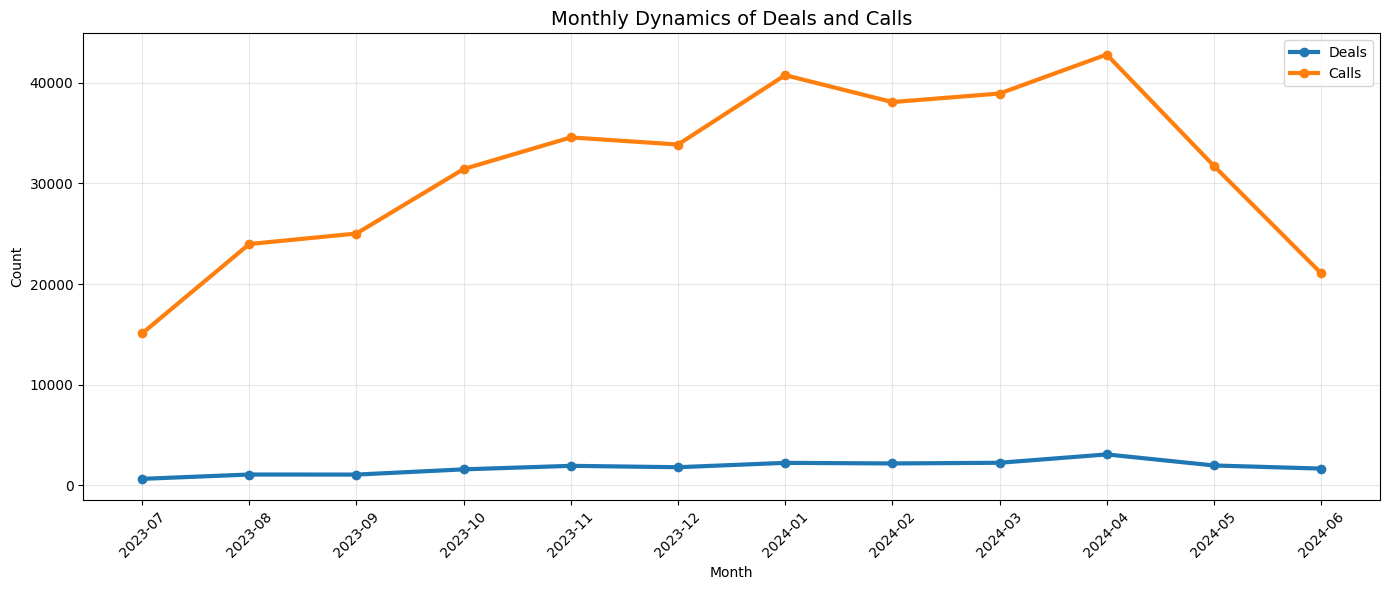

In [12]:
trend = deals_df.copy()
trend["Created_month"] = trend["Created Date"].dt.to_period("M")

trend = trend.groupby("Created_month").agg(
    Deals=("Id", "count"),
    Calls=("Calls_count", "sum")
).reset_index()

plt.figure(figsize=(14, 6))

# Deals line
plt.plot(
    trend["Created_month"].astype(str),
    trend["Deals"],
    label="Deals",
    color="#1f77b4",
    linewidth=3,
    marker="o"
)

# Calls line
plt.plot(
    trend["Created_month"].astype(str),
    trend["Calls"],
    label="Calls",
    color="#ff7f0e",
    linewidth=3,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Dynamics of Deals and Calls", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### 🔍 Insight
 ✔ Calls significantly exceed deals → potential to grow CR  
 ✔ January & April — peak activity and best months for calls  
 ✔ After January & April — decline affecting deals  
 ✔ Deals remain stable even when calls drop  
 ✔ Correlation exists but is weak → manager efficiency matters

## #️⃣ 10. Analysis of Payment Types / Products / Education Formats

### 🔹 10.1. Payment Type Analysis

In [13]:
payment_perf = (
    deals_df.groupby("Payment Type")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

payment_perf["CR"] = payment_perf["Deals_won"] / payment_perf["Deals_count"].replace(0, np.nan)
payment_perf["AOV"] = payment_perf["Revenue"] / payment_perf["Deals_won"].replace(0, np.nan)

payment_perf = payment_perf.round(2)

product_perf = payment_perf[
    ~payment_perf["Payment Type"].isin(["#REF!", "Unknown"])
]

payment_sorted = payment_perf.sort_values("Revenue", ascending=False)
payment_sorted

,Payment Type,Deals_count,Deals_won,Revenue,CR,AOV
1,Partial Payment,3197,786,3356385.0,0.25,4270.21
0,One Payment,951,55,182500.0,0.06,3318.18
2,Recurring Payments,7,2,600.0,0.29,300.00
3,Unknown,17438,15,0.0,0.00,0.00


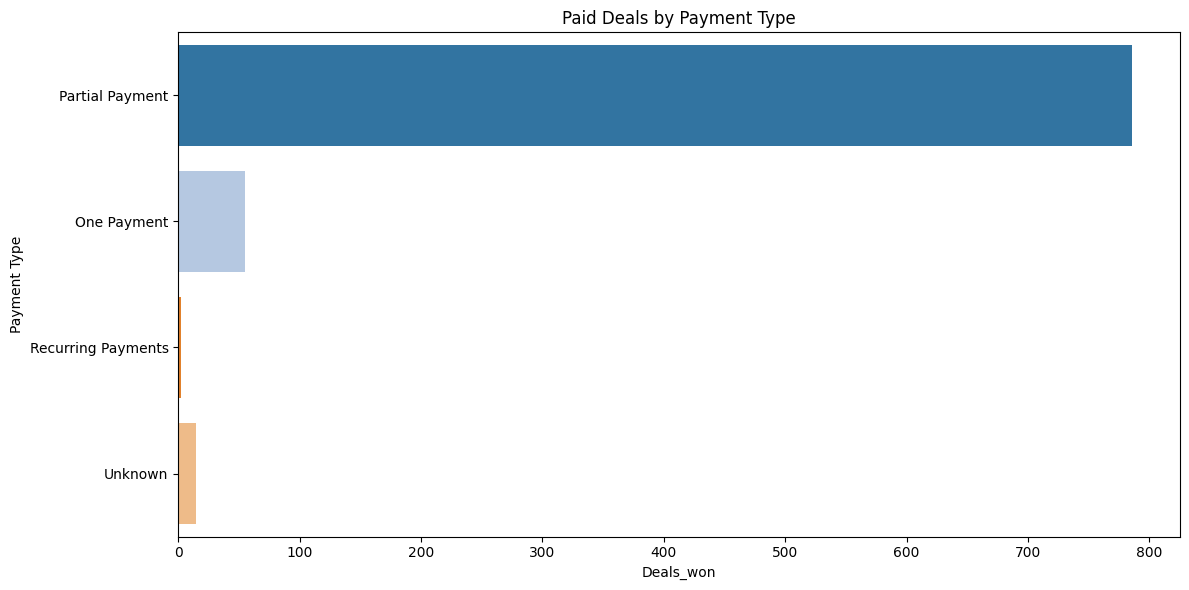

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=payment_sorted,
    x="Deals_won",
    y="Payment Type",
    hue="Payment Type",
    palette="tab20",
    dodge=False,
    legend=False
)
plt.title("Paid Deals by Payment Type")
plt.xlabel("Deals_won")
plt.ylabel("Payment Type")
plt.tight_layout()
plt.show()

### 📌 Insight
 - Partial Payment + One Payment generate the majority of sales.

 - Recurring Payments — highest‑quality payment type.

### 🔹 10.2. Product Analysis

In [15]:
product_perf = (
    deals_df.groupby("Product")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

product_perf["CR"] = product_perf["Deals_won"] / product_perf["Deals_count"].replace(0, np.nan)
product_perf["AOV"] = product_perf["Revenue"] / product_perf["Deals_won"].replace(0, np.nan)

product_perf = product_perf.round(2)

product_perf = product_perf[
    ~product_perf["Product"].isin(["#REF!", "Unknown"])
]

product_sorted = product_perf.sort_values("Deals_won", ascending=False)
product_sorted

,Product,Deals_count,Deals_won,Revenue,CR,AOV
0,Digital Marketing,1990,474,2241840.0,0.24,4729.62
2,UX/UI Design,1022,229,932365.0,0.22,4071.46
3,Web Developer,575,137,365280.0,0.24,2666.28
1,Other,18006,18,0.0,0.00,0.00


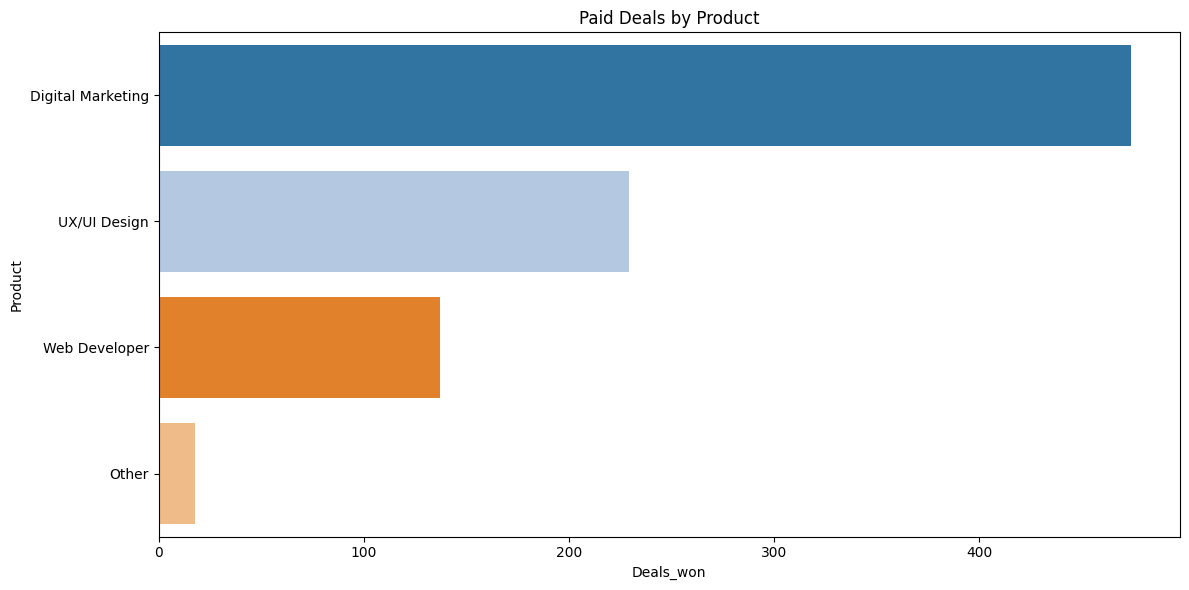

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=product_sorted,
    x="Deals_won",
    y="Product",
    hue="Product",
    palette="tab20",
    dodge=False,
    legend=False
)
plt.title("Paid Deals by Product")
plt.xlabel("Deals_won")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### 📌 Insight
 - Digital Marketing + UX/UI Design — core business products.

 - Web Developer — highest CR among products.

### 🔹 10.3. Education Type Analysis

In [18]:
edu_perf = (
    deals_df.groupby("Education Type")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

edu_perf["CR"] = edu_perf["Deals_won"] / edu_perf["Deals_count"].replace(0, np.nan)
edu_perf["AOV"] = edu_perf["Revenue"] / edu_perf["Deals_won"].replace(0, np.nan)

edu_perf = edu_perf.round(2)

edu_perf = edu_perf[
    ~edu_perf["Education Type"].isin(["#REF!", "Unknown"])
]

edu_sorted = edu_perf.sort_values("Deals_won", ascending=False)
edu_sorted

,Education Type,Deals_count,Deals_won,Revenue,CR,AOV
2,Morning,2895,662,3089270.0,0.23,4666.57
1,Evening,404,171,381765.0,0.42,2232.54


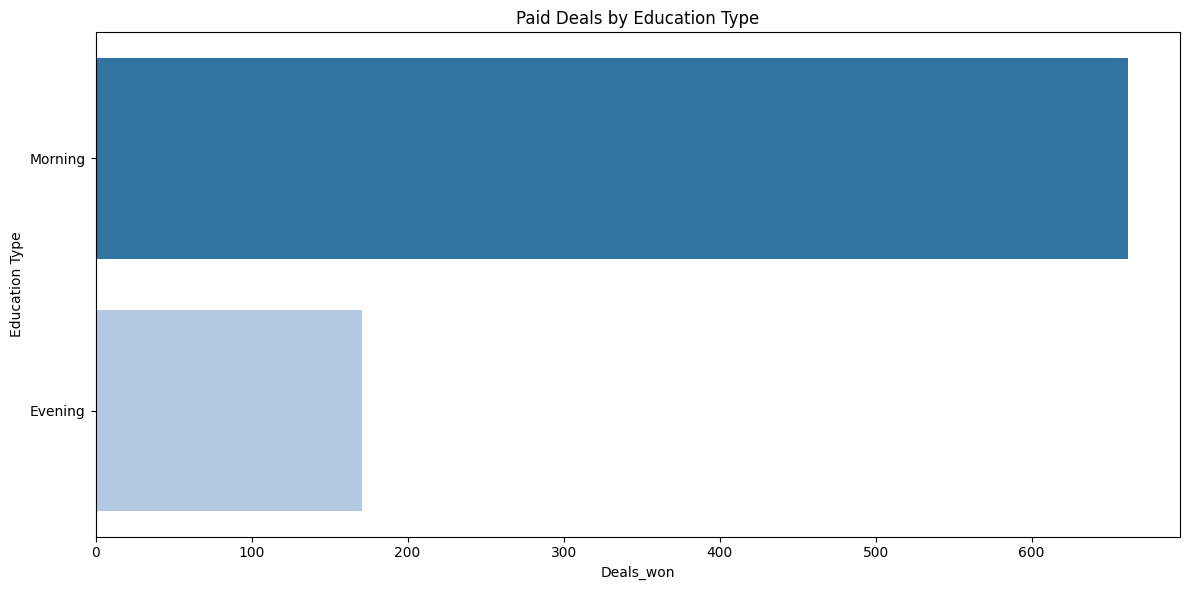

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=edu_sorted,
    x="Deals_won",
    y="Education Type",
    hue="Education Type",
    palette="tab20",
    dodge=False,
    legend=False
)
plt.title("Paid Deals by Education Type")
plt.xlabel("Deals_won")
plt.ylabel("Education Type")
plt.tight_layout()
plt.show()

### 📌 Insight
 - Morning — mass‑market format.

 - Evening — premium format (CR = 42%).

## #️⃣ 📌 11. Combined Category Ranking

In [20]:
payment_sorted["Category"] = "Payment Type"
product_sorted["Category"] = "Product"
edu_sorted["Category"] = "Education Type"

payment_sorted["Name"] = payment_sorted["Payment Type"]
product_sorted["Name"] = product_sorted["Product"]
edu_sorted["Name"] = edu_sorted["Education Type"]

payment_rank = payment_sorted[["Category", "Name", "Deals_count", "Deals_won", "Revenue", "CR", "AOV"]]
product_rank = product_sorted[["Category", "Name", "Deals_count", "Deals_won", "Revenue", "CR", "AOV"]]
edu_rank = edu_sorted[["Category", "Name", "Deals_count", "Deals_won", "Revenue", "CR", "AOV"]]

full_rank = pd.concat([payment_rank, product_rank, edu_rank], ignore_index=True)

full_rank = full_rank[
    ~full_rank["Name"].isin(["#REF!", "Unknown"])
]

full_rank = full_rank.sort_values("Deals_count", ascending=False).reset_index(drop=True)
full_rank = full_rank.round(2)
full_rank

,Category,Name,Deals_count,Deals_won,Revenue,CR,AOV
0,Product,Other,18006,18,0.0,0.00,0.00
1,Payment Type,Partial Payment,3197,786,3356385.0,0.25,4270.21
2,Education Type,Morning,2895,662,3089270.0,0.23,4666.57
3,Product,Digital Marketing,1990,474,2241840.0,0.24,4729.62
4,Product,UX/UI Design,1022,229,932365.0,0.22,4071.46
5,Payment Type,One Payment,951,55,182500.0,0.06,3318.18
6,Product,Web Developer,575,137,365280.0,0.24,2666.28
7,Education Type,Evening,404,171,381765.0,0.42,2232.54
8,Payment Type,Recurring Payments,7,2,600.0,0.29,300.00


### 🔹 Revenue by Category

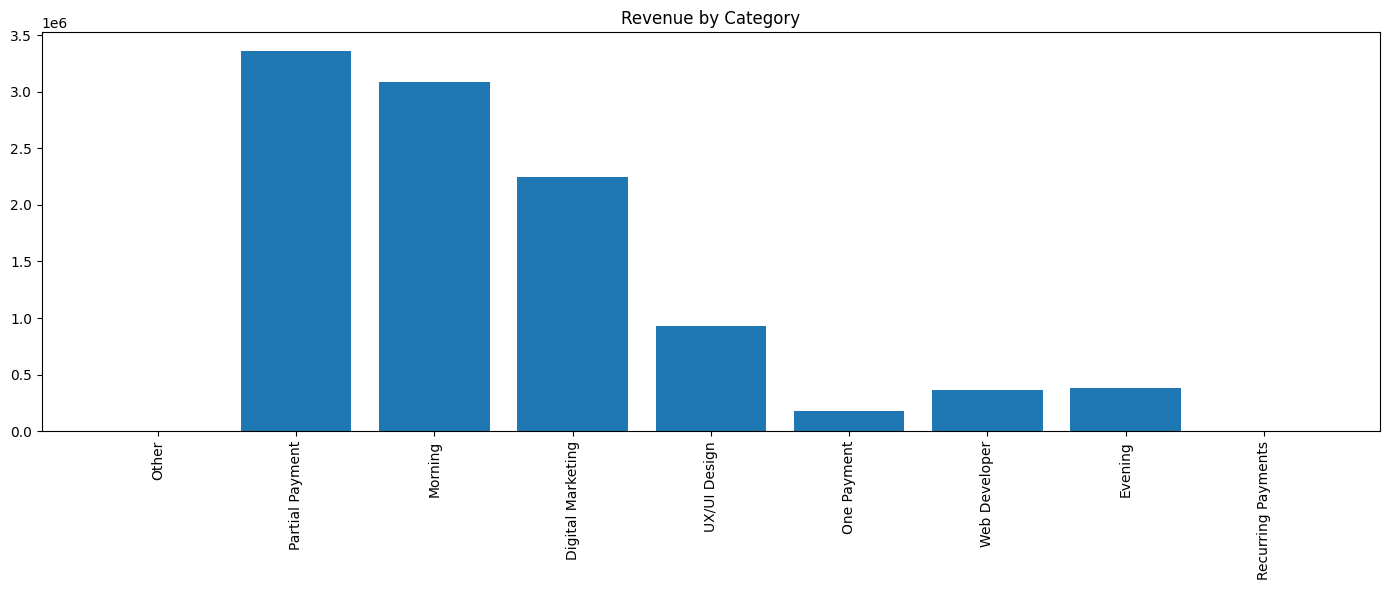

In [21]:
plt.figure(figsize=(14, 6))
plt.bar(full_rank["Name"], full_rank["Revenue"])
plt.xticks(rotation=90)
plt.title("Revenue by Category")
plt.tight_layout()
plt.show()

### 🔹 CR by Category

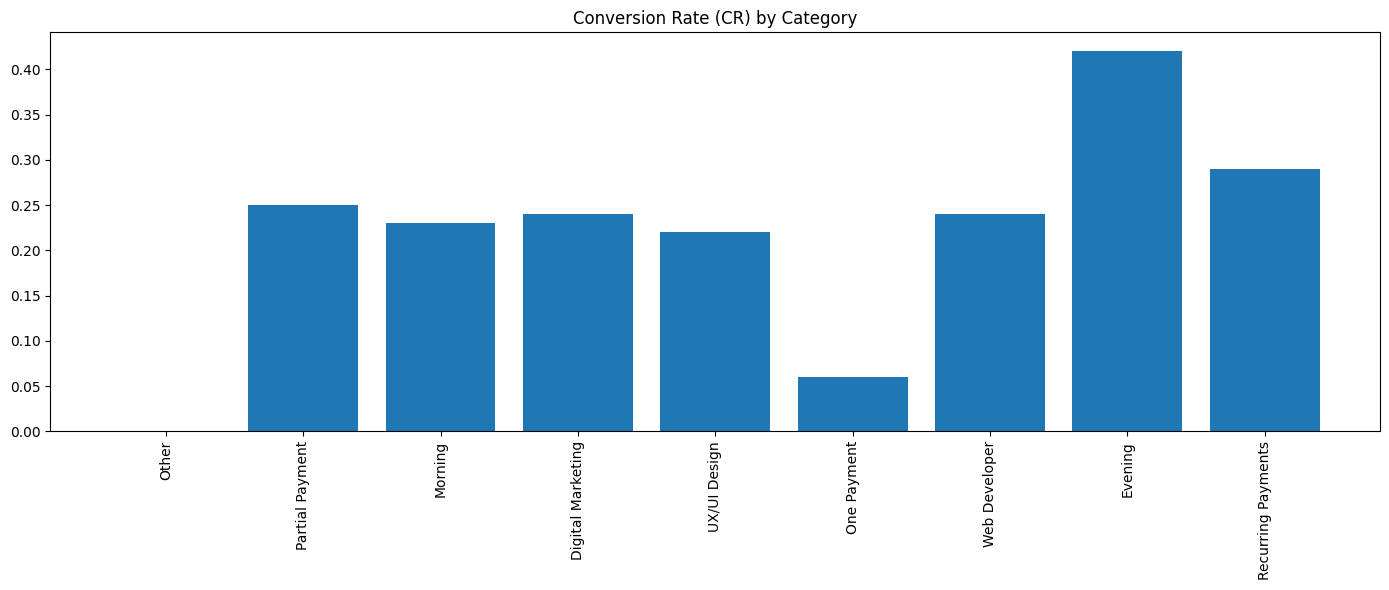

In [22]:
plt.figure(figsize=(14, 6))
plt.bar(full_rank["Name"], full_rank["CR"])
plt.xticks(rotation=90)
plt.title("Conversion Rate (CR) by Category")
plt.tight_layout()
plt.show()

## 🚀 Campaign Effectiveness Summary
The business relies on mass‑market products and formats (Digital Marketing, Morning), while sales quality is driven by niche directions (Evening, Web Developer, Recurring Payments).  
Marketing performs efficiently and delivers profitable campaigns, but the sales department loses part of the potential due to inconsistent work and weak products (Data Analytics, Find Yourself in IT), which require optimization or replacement.

## #️⃣ 💾 12. Saving

In [23]:
deals_df.to_excel("Deals_clean.xlsx", index=False)